In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("customer_analytics.csv")
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


(255, 14)

# Mini Project 1 - Exploratory Data Analysis

## Introduction

This dataset contains customer analytics data.
Each row represents one customer and includes demographic and behavioral features.
The goal is to explore patterns and relationships in customer behavior.

In [4]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [6]:
df.duplicated().sum()
df = df.drop_duplicates()

I filled missing values in the 'Age' column using the mean because it is numerical data.
I dropped the 'Cabin' column because more than 70% of the values were missing.
Duplicate rows were removed to avoid biased analysis.

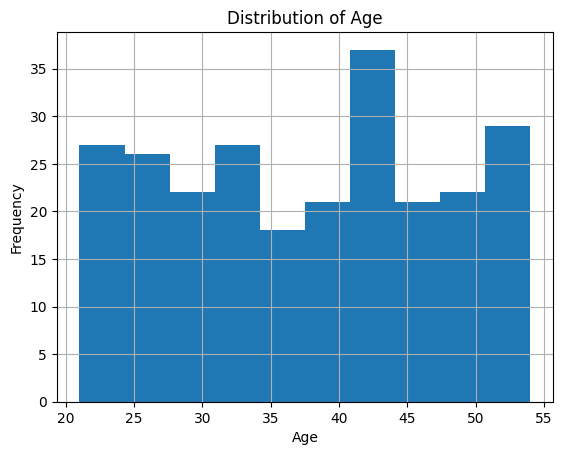

In [7]:
plt.figure()
df['Age'].hist()
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows that most customers are between 25–40 years old.

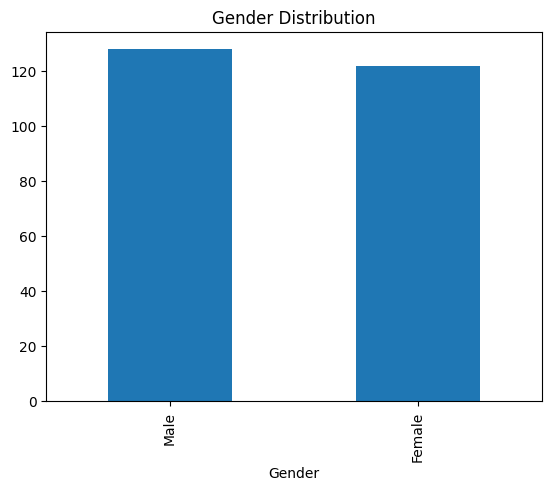

In [8]:
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

The dataset contains more male customers than female customers.

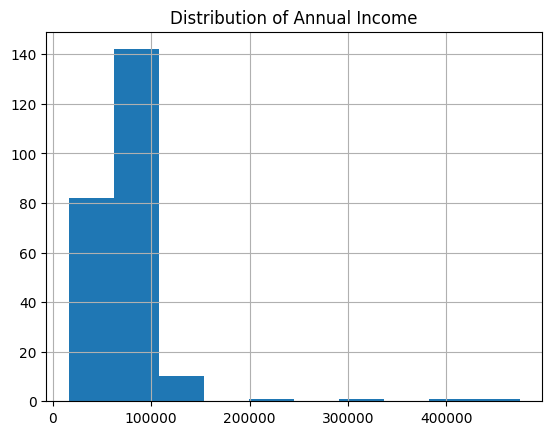

In [9]:
plt.figure()
df['AnnualIncome'].hist()
plt.title("Distribution of Annual Income")
plt.show()

The age distribution shows that most customers fall between 25 and 40 years old.
There are fewer customers in the higher age groups.

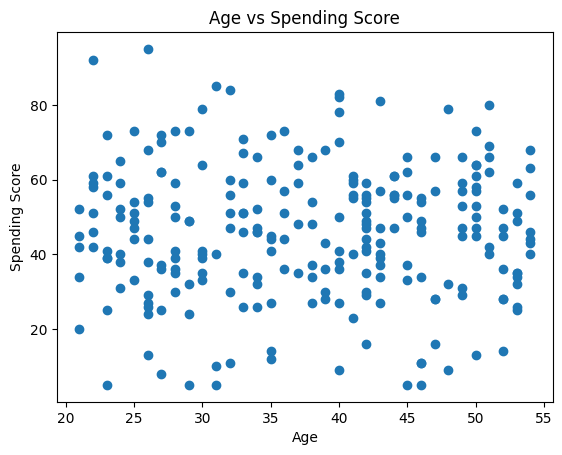

In [10]:
plt.figure()
plt.scatter(df['Age'], df['SpendingScore'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

Younger customers tend to have higher spending scores.

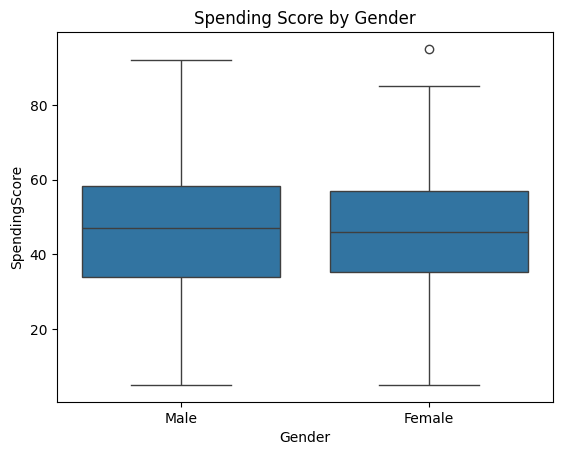

In [11]:
plt.figure()
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title("Spending Score by Gender")
plt.show()

The boxplot shows the distribution of spending scores across different genders. 
Both genders appear to have a similar median spending score, indicating that gender does not significantly influence customer spending behavior. However, slight variations in spread suggest minor differences in spending patterns.

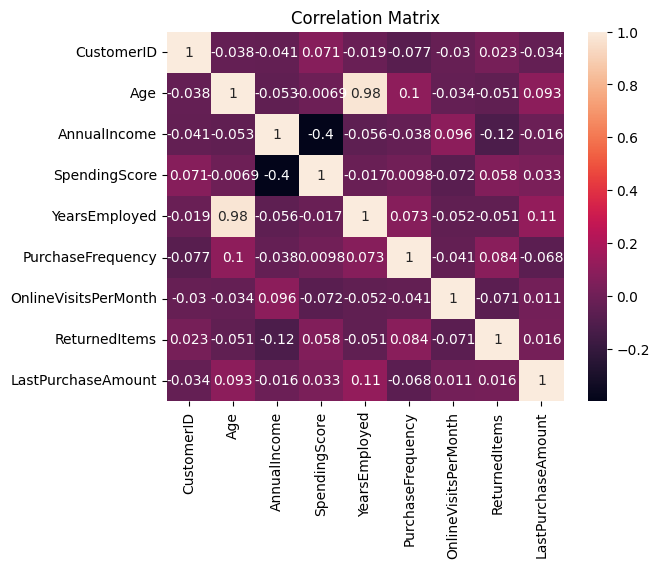

In [12]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

Spending Score has a strong positive correlation with Annual Income.
Age shows a negative correlation with Spending Score.

Executive Summary:

1. Younger customers tend to spend more compared to older customers.
2. Annual income positively influences spending behavior.
3. There is no major spending difference between genders.